# Manuscript figures, tables, and supporting checks

This notebook rebuilds the manuscript's **two figures and three tables**
from experiment outputs. It also displays the 20-seed non-shifted
comparison and adaptive expert-utilization records.

**Default: recorded results.** With `RUN_FRESH = False`, archived CSVs
are copied into `outputs/recorded/` and the figures and tables are rebuilt;
no models are trained. Set `RUN_FRESH = True` to regenerate the synthetic
data and train the original models in `outputs/rerun/`. The mode and
result origin are printed below. Timings from a fresh run are new
measurements and are not expected to equal the manuscript's timings.

The original model modules are copied unchanged. No hyperparameter
optimization is used in either mode. Run all cells in order with the
repository's Python 3.12 environment.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / "reproduce.py").is_file()
     and (candidate / "moe_poc").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook with the working directory inside the repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from reproduction.pipeline import reproduce

RUN_FRESH = False
INCLUDE_MATCHED_SEEDS = True
MODE = "rerun" if RUN_FRESH else "recorded"
print("Repository root located.")
print(f"Selected mode: {MODE}; matched-seed comparison: {INCLUDE_MATCHED_SEEDS}")


Repository root located.
Selected mode: recorded; matched-seed comparison: True


In [2]:
RUN = reproduce(
    ROOT,
    mode="rerun" if RUN_FRESH else "recorded",
    include_seeds=INCLUDE_MATCHED_SEEDS,
)
PAPER = RUN / "paper"
manifest = json.loads((RUN / "run_manifest.json").read_text(encoding="utf-8"))
display(Markdown(
    f"**Mode:** {manifest['mode']}  \n"
    f"**Result origin:** {manifest['result_origin']}  \n"
    f"**Status:** {manifest['status']}  \n"
    f"**Outputs:** `{PAPER.relative_to(ROOT).as_posix()}`"
))


Rebuilding manuscript outputs from recorded experiment CSVs (no training).


Complete: outputs/recorded/paper


**Mode:** recorded  
**Result origin:** original archived experiments  
**Status:** complete  
**Outputs:** `outputs/recorded/paper`

## Figure 1 — Distribution shift

The original plotting function displays the liquidus-temperature
distributions and withheld high-temperature region for each family.
These data produce 720 base observations, 90 adaptation observations,
and an untouched 90-observation shifted test set.


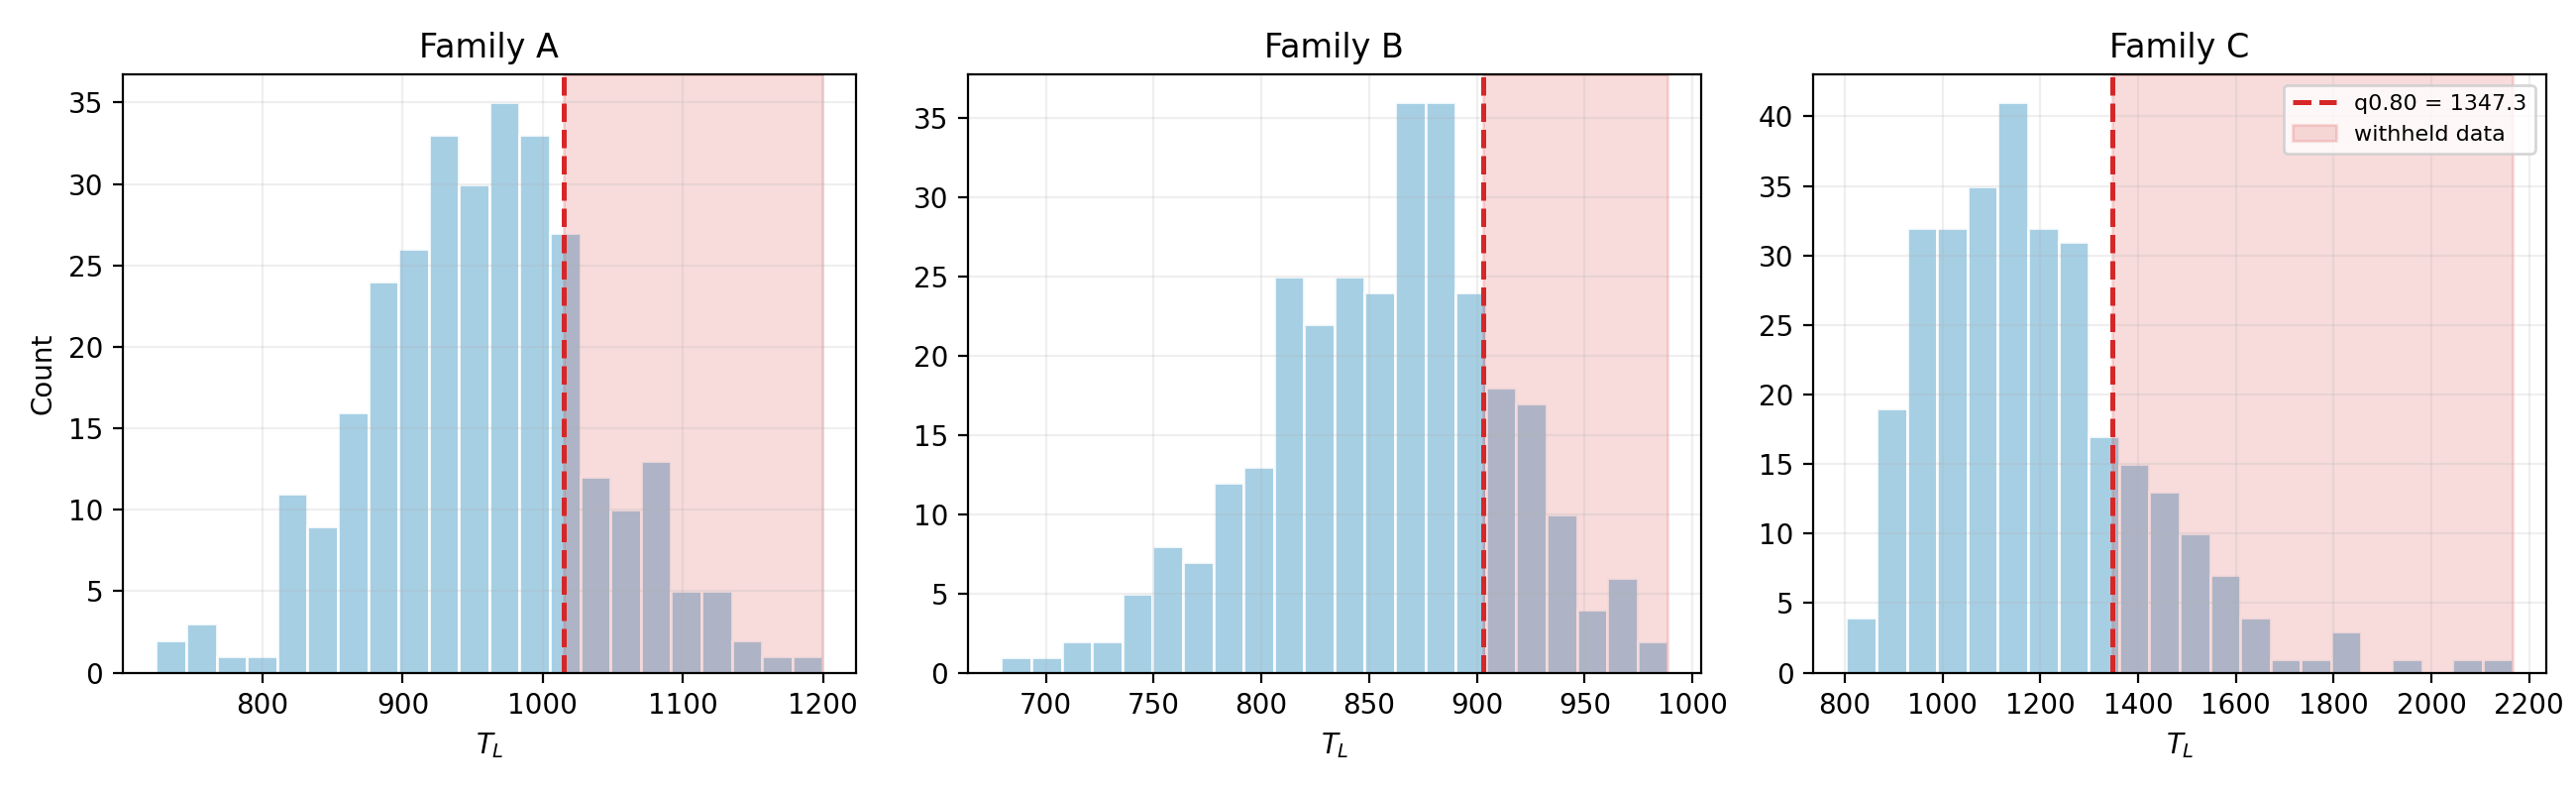

In [3]:
display(Image(filename=str(PAPER / "figure_1_distribution.png")))


## Table 1 — Final shifted-test predictive performance

All six strategies are evaluated on the same 90 shifted-test observations
after all 90 adaptation observations are available. MAE is in temperature
units; $R^2$ is dimensionless. Values below use three decimal places.


In [4]:
table_1 = pd.read_csv(PAPER / "table_1_final_metrics.csv")
display(table_1.rename(columns={"model": "Model"}).style.format({"MAE": "{:.3f}", "R2": "{:.3f}"}).hide(axis="index"))


Model,MAE,R2
Retrained MoE,10.416,0.997
Retrained NN,11.028,0.997
Adaptive MoE,15.790,0.990
Static NN,25.224,0.977
Static MoE,37.287,0.961
Adaptive MoE shuffled,202.862,0.130


## Figure 2 — Incremental learning curve

The original plotting function compares shifted-test performance at
0%, 20%, 40%, 60%, 80%, and 100% of the available adaptation data.


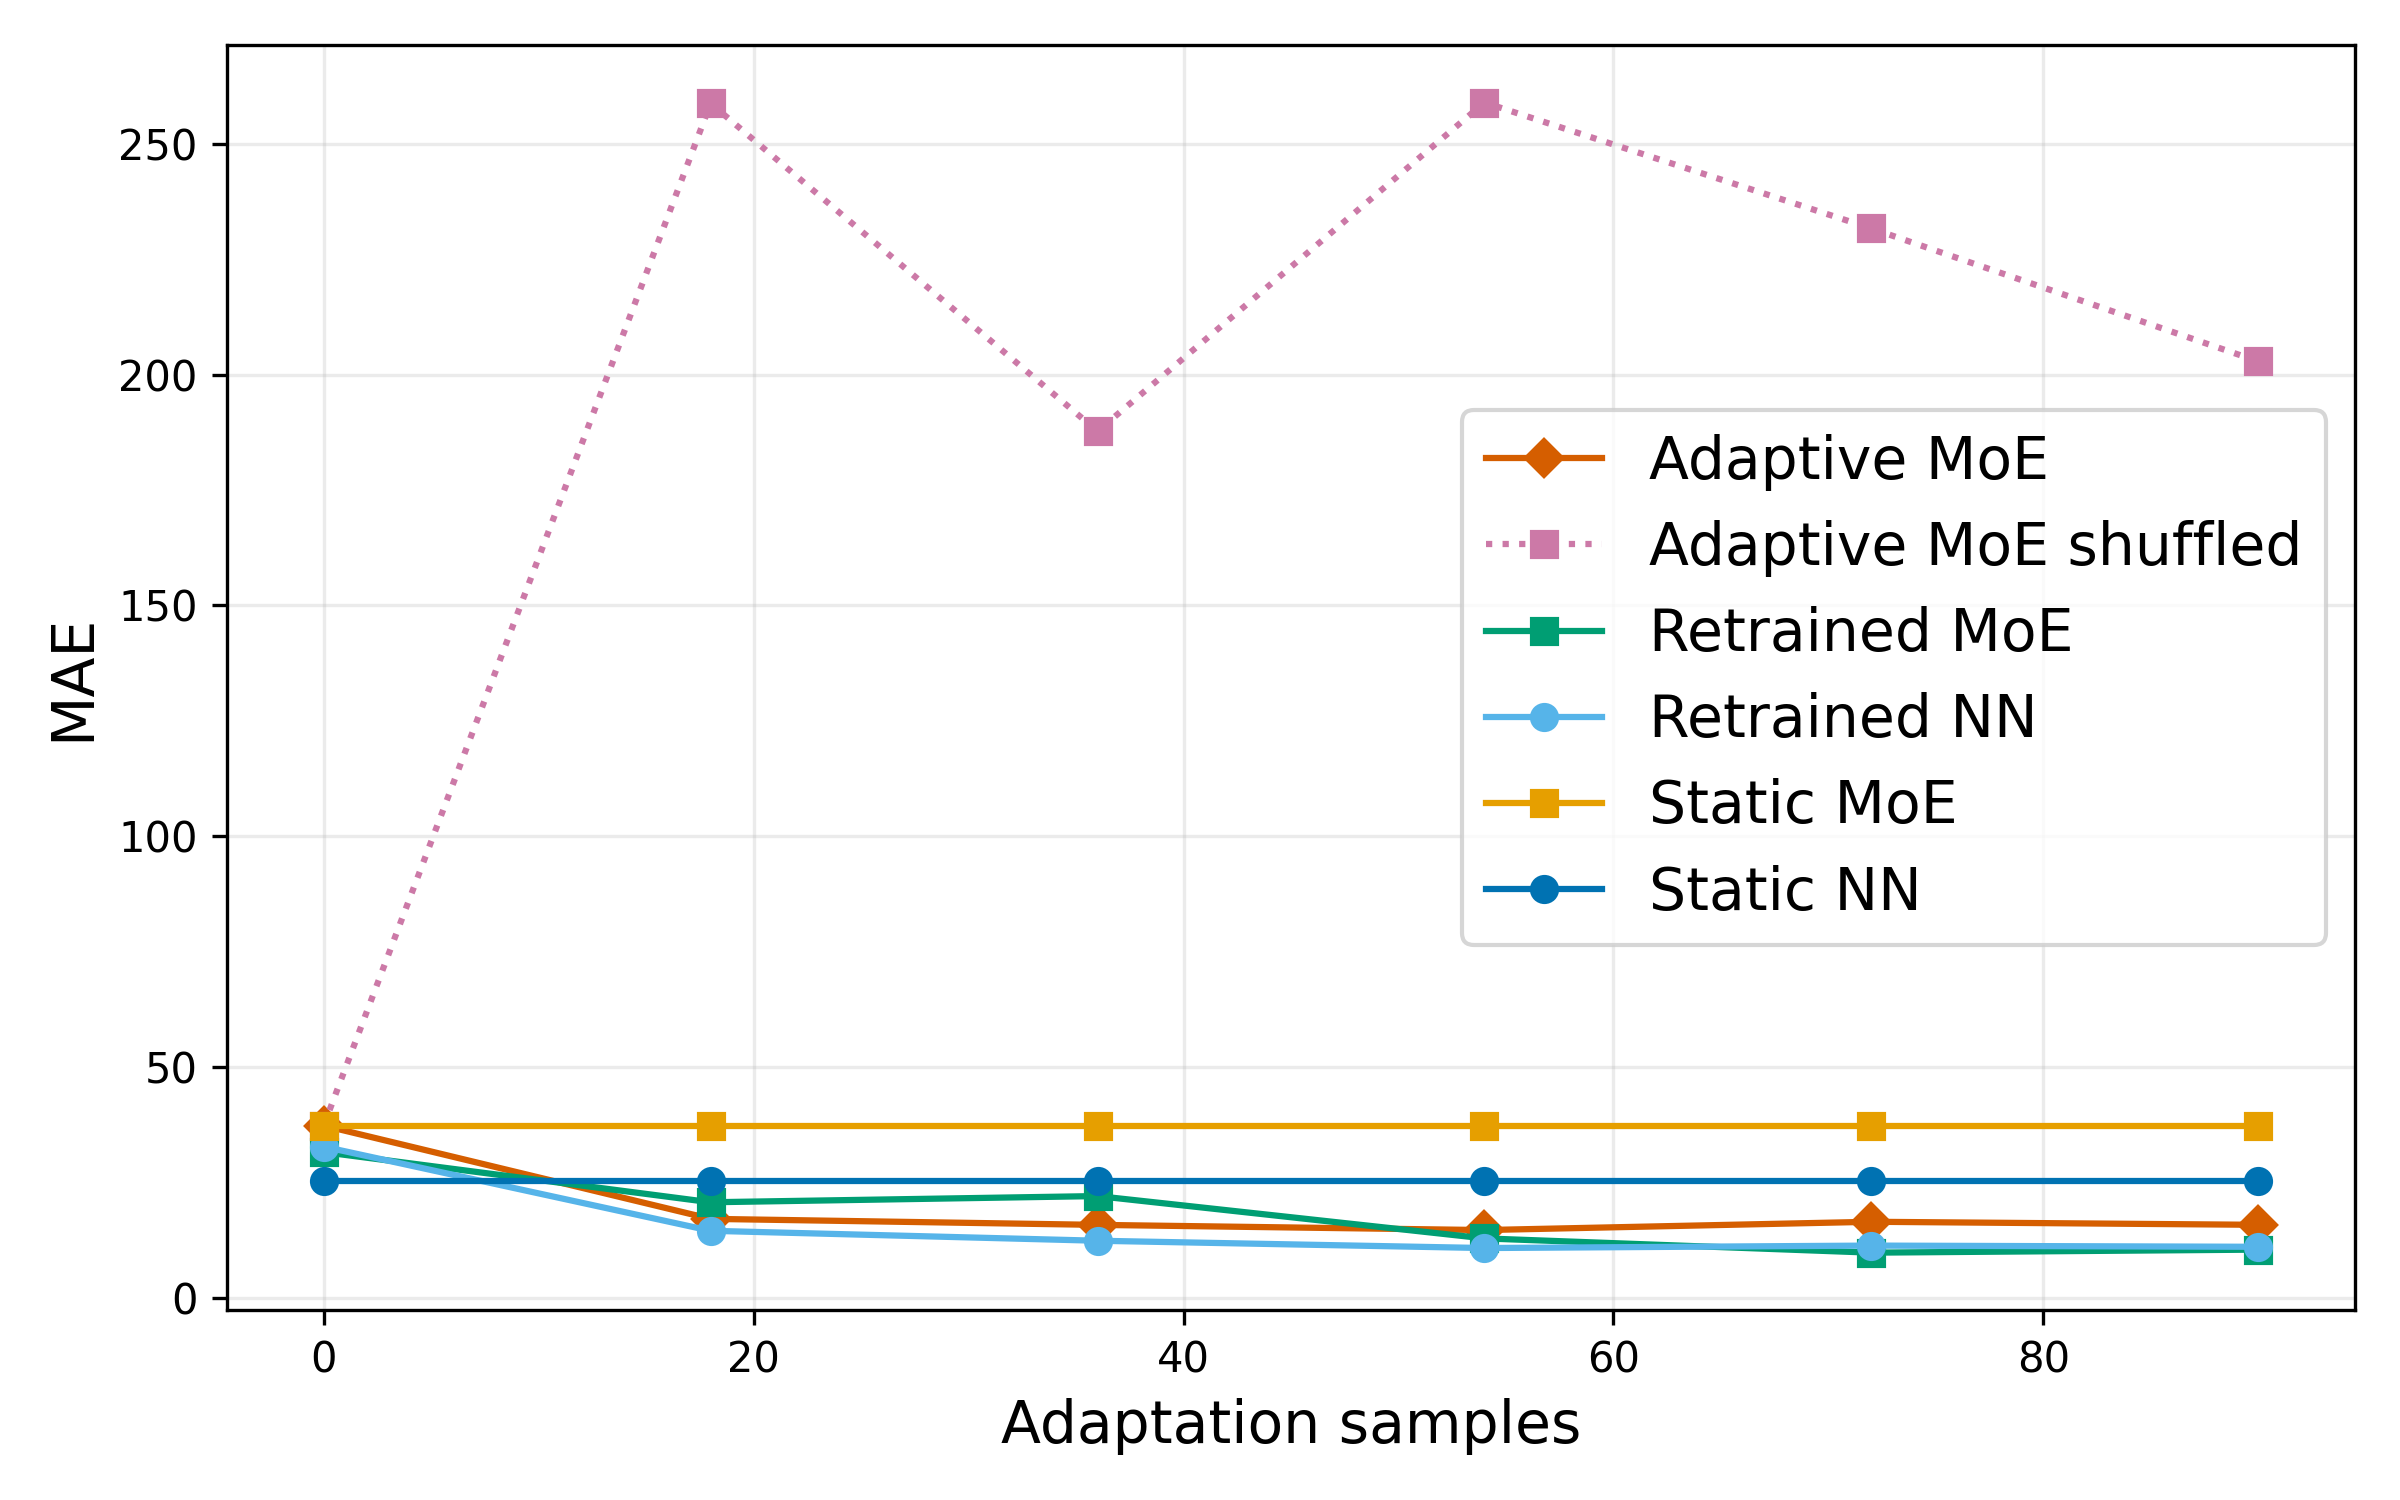

In [5]:
display(Image(filename=str(PAPER / "figure_2_learning_curve.png")))


## Table 2 — Initial training and update times

Times are wall-clock seconds, displayed to two decimal places.
Checkpoint percentages refer to the cumulative fraction of the 90
adaptation observations. Total update time excludes initial training.
Both adaptive variants inherit the Static MoE's initial fit cost;
those three initial entries describe one shared fit, not three fits.

The archived Table 1 scores and Table 2 times are extracted from the
same original incremental-comparison CSV. Each model/checkpoint time
is counted once using its `ALL` row; family rows repeat that time.


In [6]:
table_2 = pd.read_csv(PAPER / "table_2_training_times.csv")
time_names = {
    "model": "Model", "initial_training_time_sec": "Initial (s)",
    **{f"update_{pct}pct_sec": f"{pct}% (s)" for pct in (20, 40, 60, 80, 100)},
    "total_update_time_sec": "Total update (s)",
}
time_display = table_2.rename(columns=time_names)
display(time_display.style.format({name: "{:.2f}" for name in time_display.columns if name != "Model"}).hide(axis="index"))


Model,Initial (s),20% (s),40% (s),60% (s),80% (s),100% (s),Total update (s)
Static NN,6.65,0.00,0.00,0.00,0.00,0.00,0.00
Static MoE,8.80,0.00,0.00,0.00,0.00,0.00,0.00
Retrained NN,3.52,2.52,3.96,3.34,3.45,4.14,17.41
Retrained MoE,10.98,8.30,12.25,14.18,15.22,12.92,62.88
Adaptive MoE,8.80,1.09,1.12,1.11,1.15,1.16,5.63
Adaptive MoE shuffled,8.80,1.10,1.15,1.16,1.21,1.16,5.78


## Table 3 — Ensemble conformal uncertainty

MPIW95 and PICP95 refer to 95% prediction intervals; MACE averages
absolute coverage errors at confidence levels 0.50, 0.60, 0.70, 0.80,
0.90, and 0.95. Coverage is reported as a fraction. Values below use
three decimal places.

This uncertainty experiment uses **22 adaptation observations for
updating and 68 for calibration**, while Table 1 uses all 90 for
updating. Its final fitted models therefore belong to a separate
evaluation protocol. For each model and confidence level, the
absolute-residual conformal interval has constant width across inputs.


In [7]:
table_3 = pd.read_csv(PAPER / "table_3_uncertainty.csv")
display(table_3.rename(columns={"model": "Model"}).style.format({"MPIW95": "{:.3f}", "PICP95": "{:.3f}", "MACE": "{:.3f}"}).hide(axis="index"))


Model,MPIW95,PICP95,MACE
Static NN,420.806,1.000,0.036
Retrained NN,344.912,1.000,0.034
Static MoE,519.095,1.000,0.049
Retrained MoE,115.070,0.978,0.051
Adaptive MoE,159.076,0.989,0.108


## Supporting result — Matched-seed non-shifted comparison

Twenty NN/MoE pairs use seeds 42–61 and one fixed, family-stratified
outer split: 576 development observations and 144 held-out base
observations. Within each pair, both architectures use the same
internal fitting/validation partition. Reported means and sample
standard deviations summarize individual fits, not an ensemble of
their predictions. This comparison quantifies training-seed variation
conditional on the fixed dataset and outer split.


In [8]:
if INCLUDE_MATCHED_SEEDS:
    seed_summary = pd.read_csv(PAPER / "non_shifted_summary.csv")
    seed_display = pd.DataFrame({
        "Model": seed_summary.model,
        "Seeds": seed_summary.n_seeds.astype(int),
        "MAE (mean ± SD)": [f"{mean:.2f} ± {sd:.2f}" for mean, sd in zip(seed_summary.MAE_mean, seed_summary.MAE_std)],
        "RMSE (mean ± SD)": [f"{mean:.2f} ± {sd:.2f}" for mean, sd in zip(seed_summary.RMSE_mean, seed_summary.RMSE_std)],
    })
    display(seed_display.style.hide(axis="index"))
else:
    print("Matched-seed comparison omitted for this run.")


Model,Seeds,MAE (mean ± SD),RMSE (mean ± SD)
NN,20,9.91 ± 0.39,12.80 ± 0.47
MoE,20,10.25 ± 0.40,13.08 ± 0.54


## Supporting result — Adaptive expert utilization

Selected experts are the experts receiving at least one hard gate
assignment before that update. The parameter percentage includes the
selected experts and the gate. These records establish which experts
were updated; they do not measure assignment stability across fully
retrained MoE models.


In [9]:
expert_utilization = pd.read_csv(PAPER / "expert_utilization.csv")
display(expert_utilization.style.format({"percent_model_params_updated": "{:.1f}"}).hide(axis="index"))


adapt_pct,n_adapt_used,selected_experts,updated_params,total_model_params,percent_model_params_updated
20,18,"0,1,2",15014,15014,100.0
40,36,"0,1,2",15014,15014,100.0
60,54,"0,1,2",15014,15014,100.0
80,72,"0,1,2",15014,15014,100.0
100,90,"0,1,2",15014,15014,100.0


## Verification and comparison with recorded values

Protocol checks verify data separation, checkpoint completeness,
timing totals, and the uncertainty split. Numerical comparisons use
`rtol=1e-5` and `atol=1e-4`; differences are reported rather than hidden
or replaced with archived values. Hardware and library builds can
change fresh numerical results, and wall-clock timings are not required
to match the archive.

In recorded mode, numerical agreement confirms that the archived
results were rebuilt correctly; it is not evidence of fresh training.


In [10]:
verification = json.loads((RUN / "verification.json").read_text(encoding="utf-8"))
display(pd.DataFrame([
    {"Check": "Protocol checks passed", "Passed": verification["all_protocol_checks_passed"]},
    {"Check": "Numeric comparisons within tolerance", "Passed": verification["all_numeric_comparisons_within_tolerance"]},
    {"Check": "Protected original modules unchanged", "Passed": manifest["original_modules_unchanged"]},
]).style.hide(axis="index"))
display(pd.DataFrame(list(verification["checks"].items()), columns=["Protocol check", "Passed"]).style.hide(axis="index"))
comparison = pd.read_csv(PAPER / "reproduction_comparison.csv")
display(comparison.style.format({"recorded": "{:.6f}", "current": "{:.6f}", "absolute_difference": "{:.6g}"}).hide(axis="index"))
print(f"Verification: {(RUN / 'verification.json').relative_to(ROOT).as_posix()}")
print(f"Comparison CSV: {(PAPER / 'reproduction_comparison.csv').relative_to(ROOT).as_posix()}")
print(f"Environment and provenance: {(RUN / 'run_manifest.json').relative_to(ROOT).as_posix()}")


Check,Passed
Protocol checks passed,True
Numeric comparisons within tolerance,True
Protected original modules unchanged,True


Protocol check,Passed
split_sizes_720_90_90,True
base_adaptation_disjoint,True
base_test_disjoint,True
adaptation_test_disjoint,True
six_models_six_checkpoints,True
no_duplicated_overall_rows,True
finite_predictive_metrics,True
uq_22_update_68_calibration,True
static_update_times_zero,True
uq_fitting_and_calibration_disjoint,True


artifact,model,metric,recorded,current,absolute_difference,within_tolerance
table_1,Retrained MoE,MAE,10.415600,10.415600,0,True
table_1,Retrained MoE,R2,0.997105,0.997105,0,True
table_1,Retrained NN,MAE,11.028378,11.028378,0,True
table_1,Retrained NN,R2,0.996851,0.996851,0,True
table_1,Adaptive MoE,MAE,15.789928,15.789928,0,True
table_1,Adaptive MoE,R2,0.990010,0.990010,0,True
table_1,Static NN,MAE,25.223767,25.223767,0,True
table_1,Static NN,R2,0.977429,0.977429,0,True
table_1,Static MoE,MAE,37.287379,37.287379,0,True
table_1,Static MoE,R2,0.960899,0.960899,0,True


Verification: outputs/recorded/verification.json
Comparison CSV: outputs/recorded/paper/reproduction_comparison.csv
Environment and provenance: outputs/recorded/run_manifest.json
